# 09 — Error Slicing

**Ziel dieses Notebooks:** ist *wo* das Modell danebenliegt — nicht *wie oft* herauszufinden.

Die Gesamtzahl „Recall 0,863" sagt, dass von 51 Ausfällen sieben übersehen werden.
Sie sagt nicht, ob sich diese sieben gleichmäßig verteilen oder ob es eine Gruppe
von Betriebszuständen gibt, in der das Modell systematisch blind ist. 

### Umfang der Zerlegung

Einzelscheiben (Hauptansicht):

- `Qualitätsvariante` (L / M / H)
- `Verschleißband`, `Drehmomentband`, `Drehzahlband`,
  `Temperaturdifferenzband`, `Leistungsband` — jeweils Quartile

Kreuzklassifikationen (zweite Ebene):

- `Qualitätsvariante` × `Verschleißband`
- `Drehmomentband` × `Drehzahlband`

Die Bandgrenzen sind **Quartile der Daten**, keine angenommenen physikalischen
Schwellen. So ist jede Gruppe ähnlich groß, und die Einteilung nimmt keinen
Ausfallmechanismus vorweg.

Bei zehn Zeilen und einem Ausfall springt der Recall zwischen 0 % und 100 %. Deshalb wird die Gruppengröße immer mitgeführt und für die Abbildungen gilt eine Mindestgröße von 50 Zeilen.

**Gerechnet wird auf der Validierungsmenge.** 

**Die Ursachenspalten kommen als Merkmal zurück** `TWF`, `HDF`, `PWF`, `OSF` und `RNF`. Sie beantworten die Frage, welche *Art* von Ausfall übersehen wird.

## 1. Vorbereitung

In [1]:
%matplotlib inline

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from src.config import load_params
from src.modeling.error_slicing import (
    KREUZE,
    MINDESTGROESSE,
    SCHEIBEN,
    auffaellige_scheiben,
    ergaenze_baender,
    gesamt,
    kreuz,
    lade_bewertungsdaten,
    nach_ursache,
    scheibe,
)
from src.utils.plotting import CMAP_SEQUENZIELL, FARBEN, nur_x_gitter, setze_stil, speichere

setze_stil()
params = load_params()
pd.set_option("display.width", 140)

## 2. Vorhersagen laden und Fehlerarten eintragen

`lade_bewertungsdaten` rechnet die Aufteilung aus den Rohdaten mit demselben
Startwert noch einmal und **prüft**, dass sie Zeile für Zeile mit
`data/processed/val.parquet` übereinstimmt. Erst diese Übereinstimmung erlaubt
es, die Ursachenspalten über den Zeilenindex zuzuordnen.

In [2]:
frame = ergaenze_baender(lade_bewertungsdaten(params))
insgesamt = gesamt(frame, params)

print(f"Validierungsmenge: {insgesamt['Zeilen']} Zeilen, {insgesamt['Ausfälle']} Ausfälle")
print(f"Schwellenwert: {frame.attrs['schwelle']}")
frame[["Qualitätsvariante", "tool_wear_min", "torque_nm", "machine_failure",
       "wahrscheinlichkeit", "vorhersage", "fehlerart"]].head()

Validierungsmenge: 1500 Zeilen, 51 Ausfälle
Schwellenwert: 0.06


,Qualitätsvariante,tool_wear_min,torque_nm,machine_failure,wahrscheinlichkeit,vorhersage,fehlerart
0,M,88,51.7,0,0.000210,0,TN
1,L,57,53.4,0,0.000361,0,TN
2,M,171,38.8,0,0.000782,0,TN
3,L,183,35.6,0,0.000532,0,TN
4,L,15,19.3,0,0.000339,0,TN


## 3. Bezugspunkt

Jede Scheibe wird gegen diese Zahlen gelesen. Ohne Bezugspunkt ist „Recall 0,667"
weder gut noch schlecht.

In [3]:
pd.DataFrame([insgesamt]).T.rename(columns={0: "gesamt"})

,gesamt
Zeilen,1500.000000
Ausfälle,51.000000
Ausfallrate,0.034000
TP,44.000000
FP,42.000000
FN,7.000000
Recall,0.862745
Precision,0.511628
F1,0.642336
Kosten EUR,126200.000000


### Precision, Recall und F1 

- **Recall** — von allen tatsächlichen Ausfällen: wie viele findet das Modell?
  Ein niedriger Recall heißt übersehene Ausfälle, und die kosten 10.000 € je Fall.
- **Precision** — von allen ausgelösten Alarmen: wie viele waren berechtigt?
  Eine niedrige Precision heißt unnötige Prüfungen zu 500 € je Fall.
- **F1** — das harmonische Mittel beider. Nützlich, um Scheiben zu vergleichen,
  aber für die Entscheidung im Betrieb zweitrangig: Dort zählt der Euro-Betrag,
  und der gewichtet einen übersehenen Ausfall zwanzigmal so hoch wie einen
  Fehlalarm.

## 4. Ausfallursache

Der AI4I-Datensatz trägt zu jedem Ausfall ein, wodurch er entstanden ist. Damit
lässt sich fragen, was keine andere Zerlegung beantworten kann: Welchen
**Mechanismus** hat das Modell gelernt, und welchen nicht?

Eine Zeile kann mehrere Ursachen tragen, deshalb überlappen sich die Gruppen.

In [4]:
ursachen = nach_ursache(frame)
ursachen.style.format({"Recall": "{:.1%}", "mittlere Wahrscheinlichkeit": "{:.3f}"}) \
    if False else ursachen.round(3)

,Ausfälle,gefunden,übersehen,Recall,mittlere Wahrscheinlichkeit
Ursache,,,,,
TWF — Werkzeugverschleiß,8,3,5,0.375,0.042
HDF — Wärmeabfuhr,12,12,0,1.000,0.749
PWF — Leistung außerhalb des Bereichs,15,15,0,1.000,0.899
OSF — Überlastung,17,17,0,1.000,0.950
RNF — Zufallsausfall,0,0,0,NaN,NaN
ohne eingetragene Ursache,2,0,2,0.000,0.000


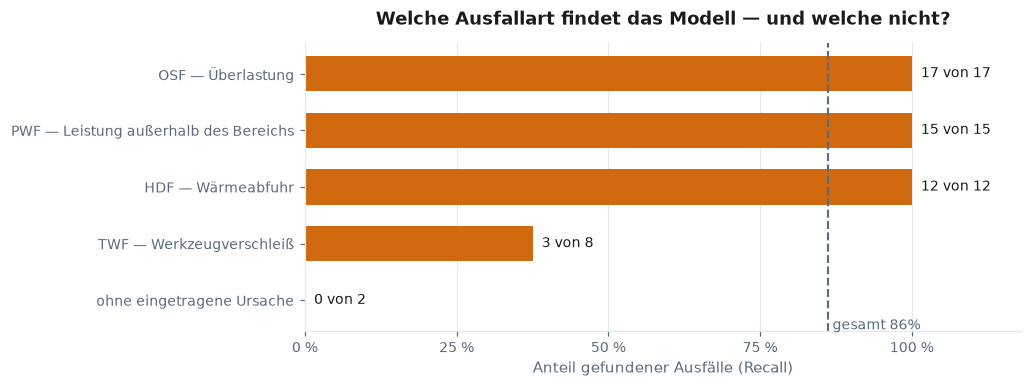

In [5]:
darstellbar = ursachen[ursachen["Ausfälle"] > 0].sort_values("Recall")

fig, ax = plt.subplots(figsize=(8.4, 3.4))
balken = ax.barh(darstellbar.index, darstellbar["Recall"], height=0.62,
                 color=FARBEN["ausfall"])
ax.axvline(insgesamt["Recall"], color=FARBEN["text_sekundaer"], linewidth=1.4,
           linestyle="--", zorder=1)
ax.text(insgesamt["Recall"], -0.45, f" gesamt {insgesamt['Recall']:.0%}",
        color=FARBEN["text_sekundaer"], fontsize=9, va="center", ha="left")

for rechteck, (name, zeile) in zip(balken, darstellbar.iterrows()):
    ax.text(rechteck.get_width() + 0.015, rechteck.get_y() + rechteck.get_height() / 2,
            f"{zeile['gefunden']:.0f} von {zeile['Ausfälle']:.0f}",
            va="center", fontsize=9, color=FARBEN["text"])

ax.set_xlim(0, 1.18)
ax.set_xticks([0, 0.25, 0.5, 0.75, 1.0])
ax.set_xticklabels(["0 %", "25 %", "50 %", "75 %", "100 %"])
ax.set_xlabel("Anteil gefundener Ausfälle (Recall)")
ax.set_title("Welche Ausfallart findet das Modell — und welche nicht?")
nur_x_gitter(ax)
speichere(fig, "16_recall_je_ursache")
plt.show()

## 5. Einzelscheiben

Gruppengröße, Ausfälle, Verwechslungsmatrix, Recall, Precision, F1 und der Anteil an den Gesamtkosten. Die Kostenspalte ist die betriebswirtschaftliche Lesart derselben Zahlen — sie zeigt, wo das Geld liegt und das ist nicht immer dort, wo der Recall am schlechtesten ist.

In [6]:
for spalte in SCHEIBEN:
    tabelle = scheibe(frame, spalte, params)
    print(f"\n{spalte}")
    print(tabelle.round(3).to_string())


Qualitätsvariante
                   Zeilen  Ausfälle  Ausfallrate    TP    FP   FN  Recall  Precision     F1  Kosten EUR  Kostenanteil
Qualitätsvariante                                                                                                    
L                   924.0      37.0        0.040  32.0  26.0  5.0   0.865      0.552  0.674     88600.0         0.702
M                   459.0      10.0        0.022  10.0  13.0  0.0   1.000      0.435  0.606     14500.0         0.115
H                   117.0       4.0        0.034   2.0   3.0  2.0   0.500      0.400  0.444     23100.0         0.183

Verschleißband
                Zeilen  Ausfälle  Ausfallrate    TP    FP   FN  Recall  Precision     F1  Kosten EUR  Kostenanteil
Verschleißband                                                                                                    
0–51             378.0       7.0        0.019   6.0   1.0  1.0   0.857      0.857  0.857     15300.0         0.121
51–105           373.0       6

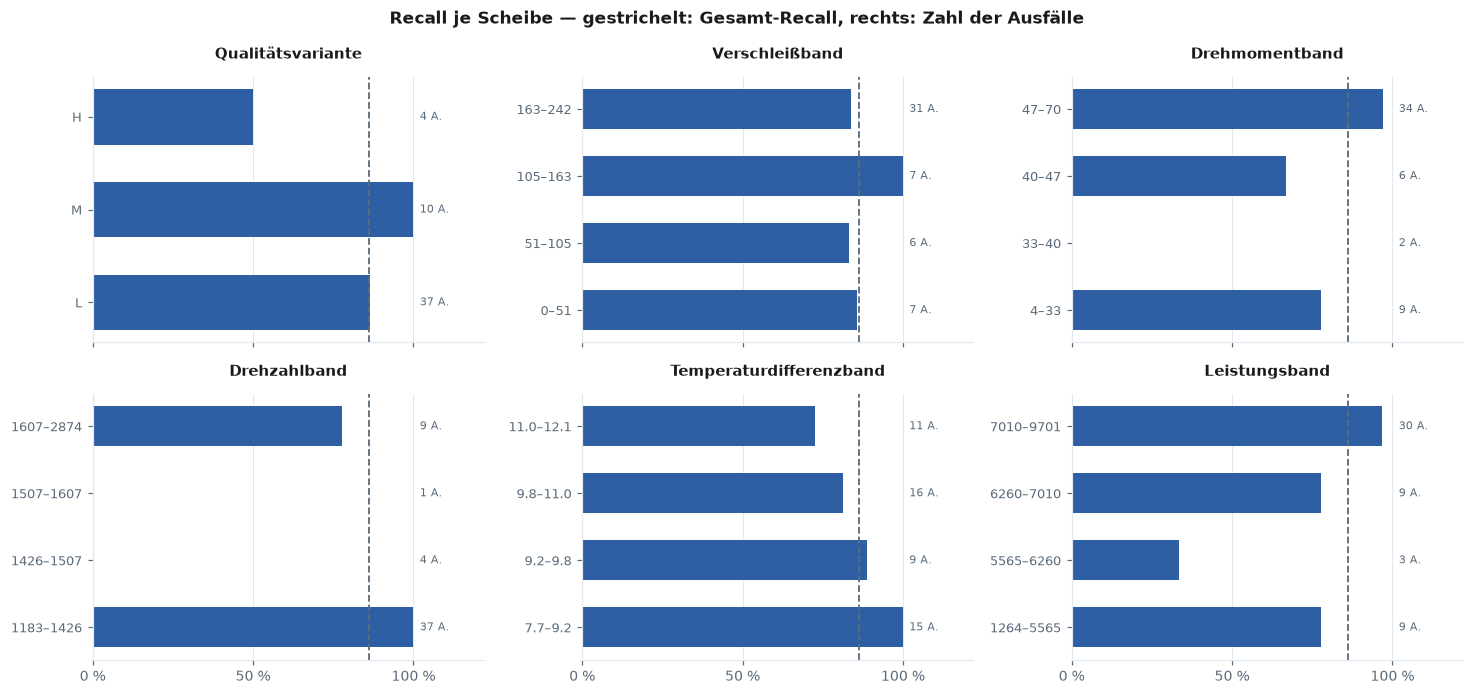

In [7]:
fig, achsen = plt.subplots(2, 3, figsize=(13.5, 6.4), sharex=True)

for ax, spalte in zip(achsen.ravel(), SCHEIBEN):
    tabelle = scheibe(frame, spalte, params)
    genug = tabelle["Zeilen"] >= MINDESTGROESSE
    ax.barh(range(len(tabelle)), tabelle["Recall"].fillna(0), height=0.6,
            color=np.where(genug, FARBEN["kein_ausfall"], FARBEN["neutral"]))
    ax.axvline(insgesamt["Recall"], color=FARBEN["text_sekundaer"],
               linewidth=1.2, linestyle="--", zorder=1)
    ax.set_yticks(range(len(tabelle)))
    ax.set_yticklabels([str(i) for i in tabelle.index], fontsize=8.5)
    for i, (_, zeile) in enumerate(tabelle.iterrows()):
        ax.text(1.02, i, f"{zeile['Ausfälle']:.0f} A.", va="center", fontsize=7.5,
                color=FARBEN["text_sekundaer"])
    ax.set_xlim(0, 1.22)
    ax.set_title(spalte, fontsize=10)
    nur_x_gitter(ax)

for ax in achsen[-1]:
    ax.set_xticks([0, 0.5, 1.0])
    ax.set_xticklabels(["0 %", "50 %", "100 %"])

fig.suptitle("Recall je Scheibe — gestrichelt: Gesamt-Recall, rechts: Zahl der Ausfälle",
             fontsize=11, fontweight="bold")
fig.tight_layout()
speichere(fig, "17_recall_je_scheibe")
plt.show()

## 6. Kreuzklassifikation

Zwei Merkmale zugleich. Felder mit weniger als 50 Zeilen bleiben leer.

In [8]:
for a, b in KREUZE[:2]:
    tabelle, groessen = kreuz(frame, a, b, "Recall", MINDESTGROESSE, params)
    print(f"\nRecall: {a} × {b}")
    print(tabelle.round(3).to_string())
    print(f"Gruppengrößen:\n{groessen.to_string()}")


Recall: Qualitätsvariante × Verschleißband
Verschleißband     0–51  51–105  105–163  163–242
Qualitätsvariante                                
L                   1.0   0.667      1.0    0.852
M                   1.0   1.000      1.0    1.000
H                   NaN     NaN      NaN      NaN
Gruppengrößen:
   0–51  51–105  105–163  163–242
L   220     224      235      245
M   128     123      105      103
H    30      26       34       27

Recall: Drehmomentband × Drehzahlband
Drehzahlband    1183–1426  1426–1507  1507–1607  1607–2874
Drehmomentband                                            
4–33                  NaN        NaN        NaN      0.778
33–40                 NaN        0.0        0.0        NaN
40–47                 1.0        0.0        NaN        NaN
47–70                 1.0        0.0        NaN        NaN
Gruppengrößen:
       1183–1426  1426–1507  1507–1607  1607–2874
4–33         1.0        1.0       53.0      321.0
33–40        5.0       94.0      225.0       52

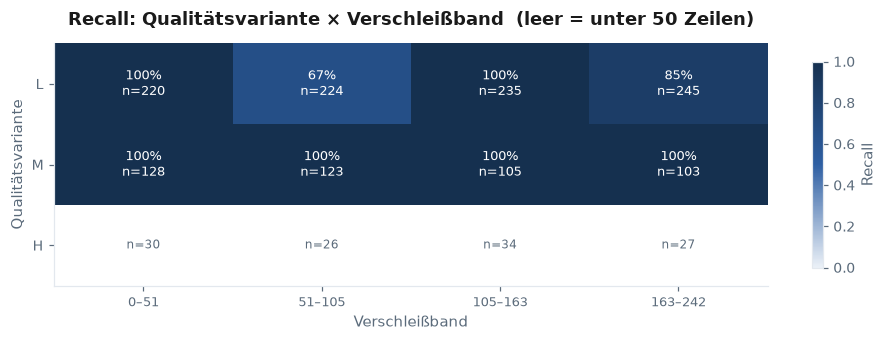

In [9]:
a, b = KREUZE[0]
tabelle, groessen = kreuz(frame, a, b, "Recall", MINDESTGROESSE, params)

fig, ax = plt.subplots(figsize=(8.8, 3.2))
bild = ax.imshow(tabelle.to_numpy(dtype=float), cmap=CMAP_SEQUENZIELL,
                 vmin=0, vmax=1, aspect="auto")

for i in range(tabelle.shape[0]):
    for j in range(tabelle.shape[1]):
        wert = tabelle.iloc[i, j]
        anzahl = groessen.iloc[i, j]
        if pd.isna(wert):
            ax.text(j, i, f"n={anzahl:.0f}", ha="center", va="center",
                    fontsize=8, color=FARBEN["text_sekundaer"])
            continue
        ax.text(j, i, f"{wert:.0%}\nn={anzahl:.0f}", ha="center", va="center",
                fontsize=8.5, color="white" if wert > 0.55 else FARBEN["text"])

ax.set_xticks(range(tabelle.shape[1]))
ax.set_xticklabels([str(c) for c in tabelle.columns], fontsize=8.5)
ax.set_yticks(range(tabelle.shape[0]))
ax.set_yticklabels(tabelle.index, fontsize=9)
ax.set_xlabel(b)
ax.set_ylabel(a)
ax.set_title(f"Recall: {a} × {b}  (leer = unter {MINDESTGROESSE} Zeilen)")
ax.grid(False)
fig.colorbar(bild, ax=ax, label="Recall", shrink=0.85)
fig.tight_layout()
speichere(fig, "18_kreuz_recall")
plt.show()

## 7. Scheiben

Sortiert nach Abstand zum Gesamt-Recall. Gruppen unter der Mindestgröße und
Gruppen ohne Ausfälle bleiben außen vor.

In [10]:
auffaellig = auffaellige_scheiben(frame, MINDESTGROESSE, params)
auffaellig.head(8).round(3)

,Scheibe,Zeilen,Ausfälle,Recall,Abstand zum Gesamt-Recall,FN,Kosten EUR,Kostenanteil
0,Drehmomentband = 33–40,376,2,0.000,-0.863,2,27000.0,0.214
1,Drehzahlband = 1426–1507,378,4,0.000,-0.863,4,44000.0,0.349
2,Drehzahlband = 1507–1607,371,1,0.000,-0.863,1,15500.0,0.123
3,Leistungsband = 5565–6260,375,3,0.333,-0.529,2,28800.0,0.228
4,Qualitätsvariante = H,117,4,0.500,-0.363,2,23100.0,0.183
5,Drehmomentband = 40–47,373,6,0.667,-0.196,2,27700.0,0.219
6,Temperaturdifferenzband = 11.0–12.1,322,11,0.727,-0.135,3,40900.0,0.324
7,Leistungsband = 1264–5565,375,9,0.778,-0.085,2,30100.0,0.239


## 8. Ergebnisse

In [11]:
from src.modeling import error_slicing

error_slicing._main()

Validierungsmenge: 1500 Zeilen, 51 Ausfälle, Schwellenwert 0.06
Gesamt: Recall 0.863  Precision 0.512  F1 0.642  Kosten 126.200 EUR

── Nach Ausfallursache ──────────────────────────────────────────────────
                                       Ausfälle  gefunden  übersehen Recall mittlere Wahrscheinlichkeit
Ursache                                                                                                
TWF — Werkzeugverschleiß                      8         3          5  37.5%                       0.042
HDF — Wärmeabfuhr                            12        12          0 100.0%                       0.749
PWF — Leistung außerhalb des Bereichs        15        15          0 100.0%                       0.899
OSF — Überlastung                            17        17          0 100.0%                       0.950
RNF — Zufallsausfall                          0         0          0    NaN                         NaN
ohne eingetragene Ursache                     2         0        

##Summary##

**Der Befund steht in der Ursachentabelle.** Von den sieben übersehenen Ausfällen
sind fünf Verschleißausfälle (`TWF`) und zwei Ausfälle ohne eingetragene Ursache.
Jeder einzelne Ausfall durch mangelnde Wärmeabfuhr (`HDF`), durch Leistung
außerhalb des zulässigen Bereichs (`PWF`) und durch Überlastung (`OSF`) wurde
gefunden — 44 von 44.

Drei dieser Mechanismen haben eine **Signatur in den Messwerten**: schlechte Wärmeabfuhr zeigt sich in einer kleinen Temperaturdifferenz bei niedriger Drehzahl, Überlastung im Produkt aus Verschleiß und Drehmoment, der Leistungsfehler im Produkt aus Drehmoment und Drehzahl. Die drei Größen sind in Notebook 04 als abgeleitete Merkmale gebaut — der Sprung von 0,743 auf 0,843 PR-AUC.

Der Verschleißausfall hat diese Signatur **nicht**. Er tritt im Datensatz als
zufälliges Ereignis in einem Verschleißfenster auf. Zwei Maschinen mit identischen
Messwerten können die eine ausfallen und die andere weiterlaufen. Kein Modell kann
das aus diesen sechs Eingangsgrößen vorhersagen, und ein Modell, das es scheinbar
doch tut, hat auswendig gelernt.

**Dieselbe Aussage in den Einzelscheiben.** Die Scheiben mit Recall 0 % liegen
alle im normalen Betriebsbereich — mittleres Drehmoment, mittlere Drehzahl,
mittlere Leistung. Dort gibt es wenige Ausfälle (ein bis vier je Gruppe) und es
sind genau die Verschleißausfälle: Betriebszustände, die unauffällig aussehen,
weil sie unauffällig *sind*. Umgekehrt liegt der Recall in den Randbändern — hohes
Drehmoment, niedrige Drehzahl, hohe Leistung — bei 97 bis 100 %.

**Das oberste Verschleißband trägt 70 % der Gesamtkosten**, obwohl sein Recall mit 83,9 % nahe am Durchschnitt liegt, weil dort 31 der 51 Ausfälle stattfinden. Die
Gruppen mit Recall 0 % tragen zusammen weniger. Für eine Verbesserung lohnt sich
der Blick auf beide Spalten.

**Die Qualitätsvariante H** fällt mit 50 % Recall auf, hat aber nur vier Ausfälle
auf 117 Zeilen. Es soll beobachtet werden, statt darauf zu handeln: Bei vier Fällen entspricht ein zusätzlicher Treffer schon 25 Prozentpunkten.

### Was folgt daraus

1. **Für den Betrieb:** Der Instandhaltung gehört gesagt, dass dieses Modell
   verschleißbedingte Ausfälle nicht zuverlässig ankündigt. Dafür ist die
   bestehende zeitbasierte Werkzeugwechselregel zuständig und bleibt es — das
   Modell ergänzt sie, es ersetzt sie nicht.
2. **Für die Überwachung:** Die Obergrenze des Recalls ist durch den
   Datensatz gesetzt, nicht durch das Modell. Das steht so im
   Überwachungskonzept und ist der Grund, warum die Qualitätsschranke bei 0,80
   liegt und nicht bei 0,95.
3. **Für ein nächstes Modell:** Ein Merkmal, das den Verschleißausfall
   ankündigt, müsste aus Daten kommen, die wir nicht haben — Schwingung,
   Stromaufnahme, Standzeit seit dem letzten Wechsel. Mehr Abstimmung an den
   vorhandenen sechs Größen bringt es nicht.